# 01 — Exploratory Data Analysis

**Group D — Grid Load Prediction**

Clean the data (median imputation baseline), then explore key variables with Matplotlib, Seaborn and Plotly (**Assignment Tasks 7, 8, 9**). Report-bound figures are saved to `reports/figures/`. The cleaned dataset is written to `data/processed/` for downstream notebooks.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
REPO = Path.cwd()
while not (REPO / "src").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
import numpy as np
import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Repo root:", REPO)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
sns.set_theme(style='whitegrid', palette='viridis')
from src.data_loading import FIGURES_DIR, PROCESSED_DIR, TARGET
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

Repo root: /home/winzer/code/python/class/aion-gridload


## Clean the data
Coerce types, drop `Record_ID`, drop rows with a missing target, median-impute the rest (justification for median vs KNN lives in the imputation experiment).

In [2]:
from src.data_loading import load_dataset
from src.preprocessing import clean_data
raw = load_dataset()
df = clean_data(raw, strategy='median')
print('Clean shape:', df.shape, '| any missing:', bool(df.isna().any().any()))
df.head()

Clean shape: (1489, 10) | any missing: False


,Region,Hour,DayOfWeek,Temperature_C,Humidity_pct,Rainfall_mm,PopulationIndex,IndustrialIndex,SolarGenerationIndex,GridLoad_MW
0,Central,20.0,0.0,26.7,52.0,3.1,93.0,89.0,0.03,850.3
1,Eastern,13.0,0.0,18.5,63.0,3.7,95.0,89.0,0.38,788.3
2,Western,14.0,4.0,22.7,90.0,3.3,71.0,55.0,0.13,548.0
3,Northern,10.0,0.0,19.6,41.0,0.1,75.0,78.0,0.45,604.6
4,Northern,12.0,0.0,27.4,88.0,0.0,86.0,58.0,0.70,546.1


In [3]:
# Persist the cleaned dataset for downstream notebooks
clean_path = PROCESSED_DIR / 'grid_load_clean.csv'
df.to_csv(clean_path, index=False)
print('Saved', clean_path.relative_to(REPO))

Saved data/processed/grid_load_clean.csv


## Task 7 — Key variables
Numeric drivers plus the target. We look at distributions, relationships to load, and correlation structure.

In [4]:
num = df.select_dtypes('number')
num.columns.tolist()

['Hour',
 'DayOfWeek',
 'Temperature_C',
 'Humidity_pct',
 'Rainfall_mm',
 'PopulationIndex',
 'IndustrialIndex',
 'SolarGenerationIndex',
 'GridLoad_MW']

## Target distribution (Matplotlib)

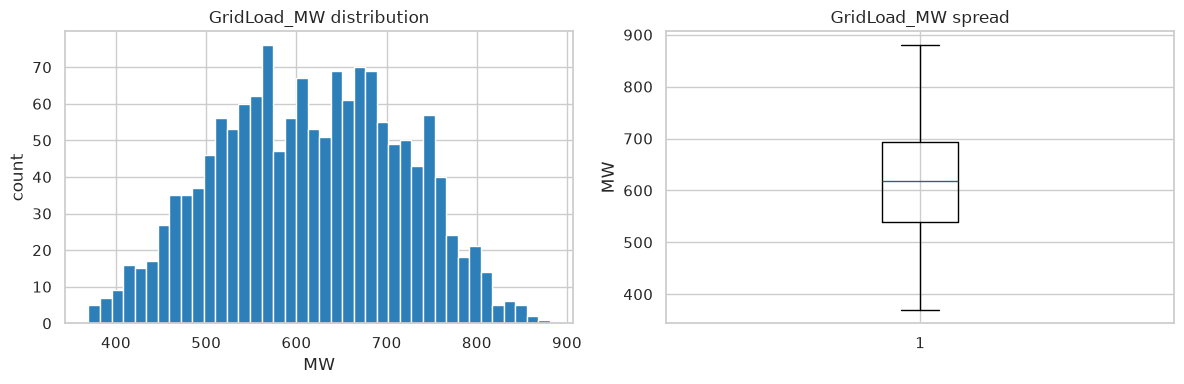

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df[TARGET], bins=40, color='#2c7fb8', edgecolor='white')
ax[0].set_title('GridLoad_MW distribution'); ax[0].set_xlabel('MW'); ax[0].set_ylabel('count')
ax[1].boxplot(df[TARGET], vert=True)
ax[1].set_title('GridLoad_MW spread'); ax[1].set_ylabel('MW')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'target_distribution.png', dpi=120)
plt.show()

## Task 8 — Correlation heatmap (Seaborn)

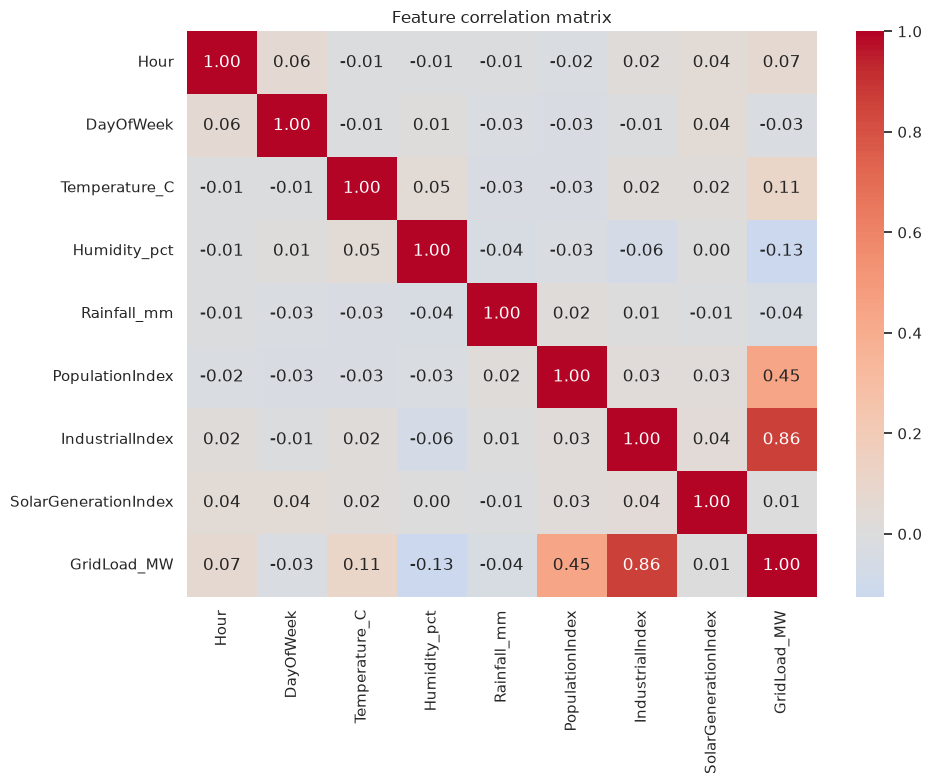

In [6]:
corr = num.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature correlation matrix')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=120)
plt.show()

In [7]:
# Correlation of each feature with the target, ranked
corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

IndustrialIndex         0.862937
PopulationIndex         0.445607
Humidity_pct           -0.125653
Temperature_C           0.105271
Hour                    0.068568
Rainfall_mm            -0.042183
DayOfWeek              -0.028850
SolarGenerationIndex    0.006692
Name: GridLoad_MW, dtype: float64

## Load by Hour and Region (Seaborn)

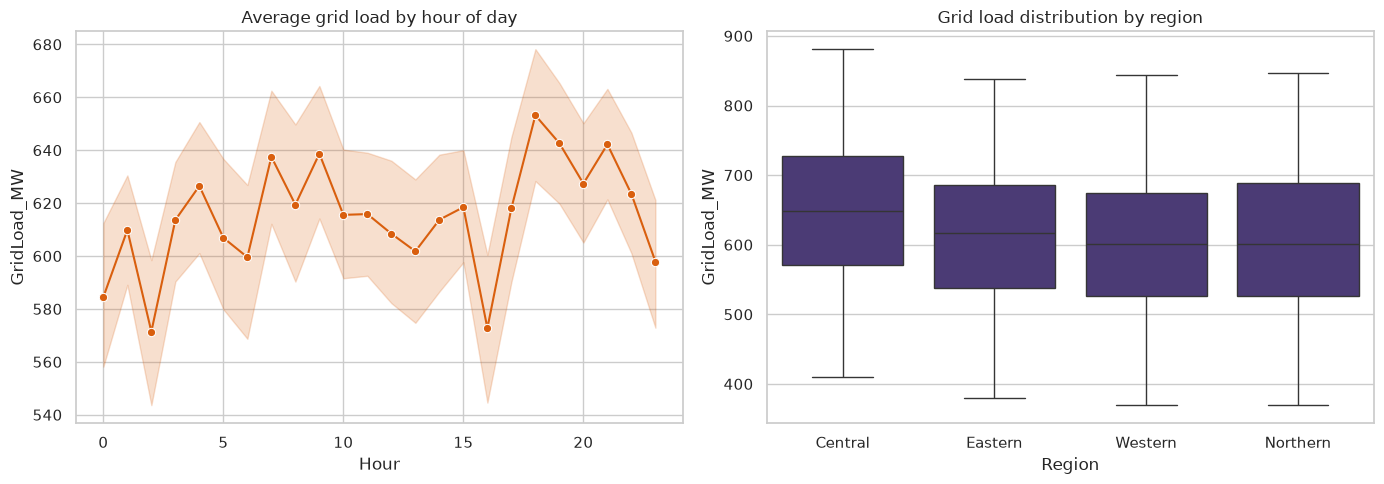

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df, x='Hour', y=TARGET, ax=ax[0], marker='o', color='#d95f0e')
ax[0].set_title('Average grid load by hour of day')
sns.boxplot(data=df, x='Region', y=TARGET, ax=ax[1])
ax[1].set_title('Grid load distribution by region')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'load_by_hour_region.png', dpi=120)
plt.show()

## Weekday vs weekend and temperature relationship (Seaborn)

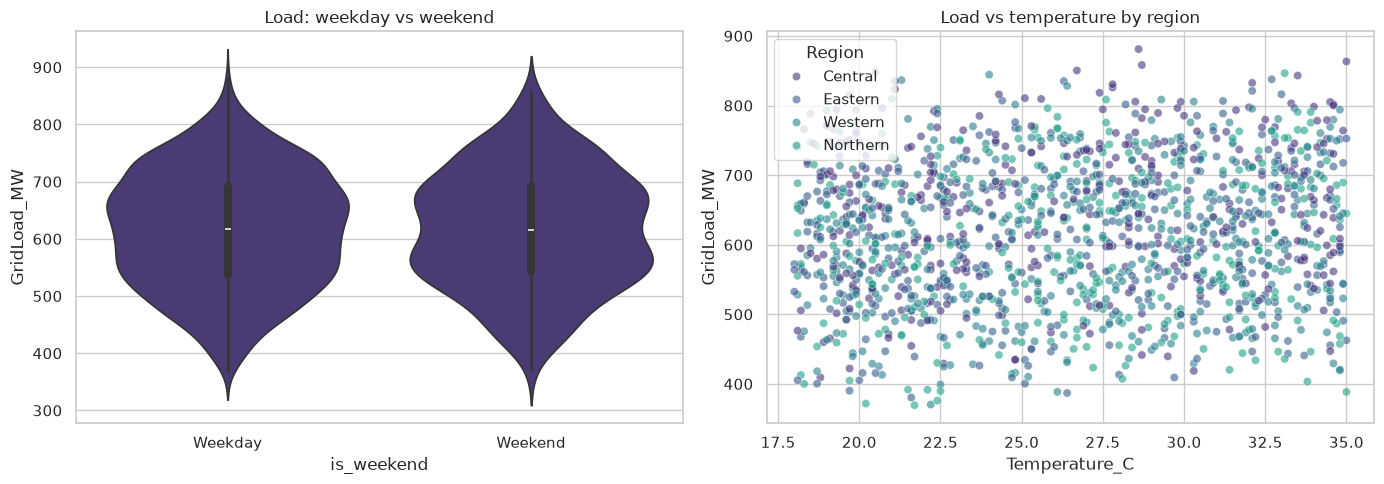

In [9]:
d = df.copy()
d['is_weekend'] = (d['DayOfWeek'] >= 5).map({True: 'Weekend', False: 'Weekday'})
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=d, x='is_weekend', y=TARGET, ax=ax[0])
ax[0].set_title('Load: weekday vs weekend')
sns.scatterplot(data=d, x='Temperature_C', y=TARGET, hue='Region', alpha=0.6, ax=ax[1])
ax[1].set_title('Load vs temperature by region')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'weekend_and_temperature.png', dpi=120)
plt.show()

## Task 8 — Interactive scatter & 3D plot (Plotly)
Saved as standalone HTML so they can be opened for the report/presentation.

In [10]:
fig = px.scatter(df, x='Temperature_C', y=TARGET, color='Region',
                 size='Humidity_pct', hover_data=['Hour', 'IndustrialIndex'],
                 title='Grid load vs temperature (bubble = humidity)')
fig.write_html(str(FIGURES_DIR / 'plotly_scatter_temp_load.html'))
fig.show()

In [11]:
fig3d = px.scatter_3d(df, x='Temperature_C', y='IndustrialIndex', z=TARGET,
                      color='Region', opacity=0.7,
                      title='Load vs Temperature vs Industrial index (3D)')
fig3d.write_html(str(FIGURES_DIR / 'plotly_3d_load.html'))
fig3d.show()

## Task 9 — Interpretation & insights
- **Strongest linear correlates** of `GridLoad_MW` are shown in the ranked table above (typically PopulationIndex / IndustrialIndex and temperature).
- **Hour-of-day** shows a clear daily load curve — demand is not flat, so cyclical hour features should help models.
- **Region** shifts the load distribution (Central highest), so region encoding matters.
- **Weekend vs weekday** and **temperature** effects motivate the engineered features in `experiments/feature_engineering_01_impact.ipynb`.
- Figures saved to `reports/figures/` for the report.